# 🚀 AMD & NVIDIA Short-Term Price Prediction System

**Objective:** Compare XGBoost · TFT · Hybrid Ensemble for next-day direction prediction  
**Inspired by:** Moghar & Hamiche (2020) — LSTM for stock market prediction  
**Assets:** AMD, NVDA + QQQ, SOXX (cross-asset signals)  
**Models:** A) XGBoost  B) Temporal Fusion Transformer  C) Hybrid (Stacking + Feature Fusion)

---
**Fixes applied vs original notebooks:**
- `yfinance` multi-ticker column alignment (level-0 vs level-1 MultiIndex)
- `engineer_features` truncated at `vol_ratio_5_20` — completed  
- `ema_12`/`ema_26` never created but referenced — fixed  
- Cross-asset column names inconsistent (`nvda_lag_*` vs `amd_lag_*`) — unified  
- `EXCLUDED_COLS` listed `nvda_lag_*` hard-coded but AMD features use `amd_lag_*` — fixed  
- `feat_cols` undefined when `FEATURE_COLS` built — fixed ordering  
- Duplicate `time_split` definition caused `IndexError` on empty df — removed duplicate  
- `train_xgboost` return statement truncated (`val_auc`: incomplete) — completed  
- `build_and_train_tft` call truncated at `max_epochs=50` — completed  
- `evaluate_model` cell truncated (`all_results` dict incomplete) — completed  
- `run_backtest` print loop truncated (`for` statement incomplete) — completed  
- `LSTM` added as Model D (paper replication) using `torch.nn` — new section added

## 1. 📦 Environment Setup & Dependencies

In [15]:
# Install required packages (run once)
import subprocess, sys

packages = [
    'yfinance', 'xgboost', 'lightgbm', 'pytorch-forecasting',
    'pytorch-lightning', 'lightning', 'scikit-learn', 'pandas', 'numpy',
    'matplotlib', 'seaborn', 'ta', 'shap', 'plotly', 'joblib',
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('✅ All dependencies installed.')

✅ All dependencies installed.


In [16]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
from datetime import datetime
from pathlib import Path

from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
import xgboost as xgb
import lightgbm as lgb
import shap

import torch
import torch.nn as nn
import lightning.pytorch as pl
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
import ta

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
pl.seed_everything(RANDOM_SEED)

plt.style.use('dark_background')
COLORS = {'AMD': '#ED1C24', 'NVDA': '#76B900', 'QQQ': '#00A8E0', 'SOXX': '#FF8C00'}

print(f'✅ Imports OK | PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}')

Seed set to 42


✅ Imports OK | PyTorch 2.11.0+cpu | CUDA: False


## 2. 📊 Data Acquisition & Preprocessing

In [3]:
CONFIG = {
    'tickers':          ['AMD', 'NVDA', 'QQQ', 'SOXX'],
    'primary':          ['AMD', 'NVDA'],
    'start_date':       '2015-01-01',
    'end_date':         datetime.today().strftime('%Y-%m-%d'),
    'train_ratio':      0.70,
    'val_ratio':        0.15,
    'test_ratio':       0.15,
    'seq_length':       60,
    'pred_horizon':     1,
    'threshold':        0.55,
    'transaction_cost': 0.001,
    'data_cache':       'data/raw_prices.parquet',
}
for d in ['data', 'models', 'results']:
    Path(d).mkdir(exist_ok=True)
print('Config ready.')

Config ready.


In [4]:
# ── FIX: robust yfinance multi-ticker extraction ──────────────────────────────
def download_data(tickers, start, end, cache_path=None):
    if cache_path and Path(cache_path).exists():
        print(f'📂 Loading cached data from {cache_path}')
        return pd.read_parquet(cache_path)
    print(f'⬇️  Downloading {tickers} …')
    raw = yf.download(tickers=tickers, start=start, end=end,
                      auto_adjust=True, progress=True)
    if cache_path:
        raw.to_parquet(cache_path)
    return raw


def extract_ohlcv(raw_df, ticker):
    """Handle both (Price, Ticker) and (Ticker, Price) MultiIndex layouts."""
    cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    if isinstance(raw_df.columns, pd.MultiIndex):
        lvl0 = raw_df.columns.get_level_values(0).unique().tolist()
        lvl1 = raw_df.columns.get_level_values(1).unique().tolist()
        if ticker in lvl0:               # (Ticker, Price) layout
            df = raw_df[ticker].copy()
        elif ticker in lvl1:             # (Price, Ticker) layout — swap
            df = raw_df.xs(ticker, axis=1, level=1).copy()
        else:
            raise KeyError(f'{ticker} not found in columns: {raw_df.columns[:8]}')
    else:
        df = raw_df.copy()
    available = [c for c in cols if c in df.columns]
    df = df[available].copy()
    df.columns = [c.lower() for c in df.columns]
    df.index = pd.to_datetime(df.index)
    return df.dropna()


raw_data = download_data(CONFIG['tickers'], CONFIG['start_date'],
                         CONFIG['end_date'], CONFIG['data_cache'])
print('\n🔍 Column structure:', raw_data.columns[:6].tolist(), '...')

price_data = {t: extract_ohlcv(raw_data, t) for t in CONFIG['tickers']}

for t, df in price_data.items():
    print(f'  {t}: {len(df):,} rows | {df.index[0].date()} → {df.index[-1].date()}')

# Common trading dates
common_dates = price_data['AMD'].index
for t in CONFIG['tickers'][1:]:
    common_dates = common_dates.intersection(price_data[t].index)
print(f'\n✅ Common trading days: {len(common_dates):,}')

⬇️  Downloading ['AMD', 'NVDA', 'QQQ', 'SOXX'] …


[*********************100%***********************]  4 of 4 completed



🔍 Column structure: [('Close', 'AMD'), ('Close', 'NVDA'), ('Close', 'QQQ'), ('Close', 'SOXX'), ('High', 'AMD'), ('High', 'NVDA')] ...
  AMD: 2,831 rows | 2015-01-02 → 2026-04-07
  NVDA: 2,831 rows | 2015-01-02 → 2026-04-07
  QQQ: 2,831 rows | 2015-01-02 → 2026-04-07
  SOXX: 2,831 rows | 2015-01-02 → 2026-04-07

✅ Common trading days: 2,831


In [5]:
print('=== Data Quality Report ===')
for ticker, df in price_data.items():
    print(f'\n{ticker}: shape={df.shape}, missing={df.isnull().sum().sum()}, '
          f'close=[{df["close"].min():.2f}, {df["close"].max():.2f}]')

=== Data Quality Report ===

AMD: shape=(2831, 5), missing=0, close=[1.62, 264.33]

NVDA: shape=(2831, 5), missing=0, close=[0.46, 207.02]

QQQ: shape=(2831, 5), missing=0, close=[89.47, 634.15]

SOXX: shape=(2831, 5), missing=0, close=[22.68, 367.77]


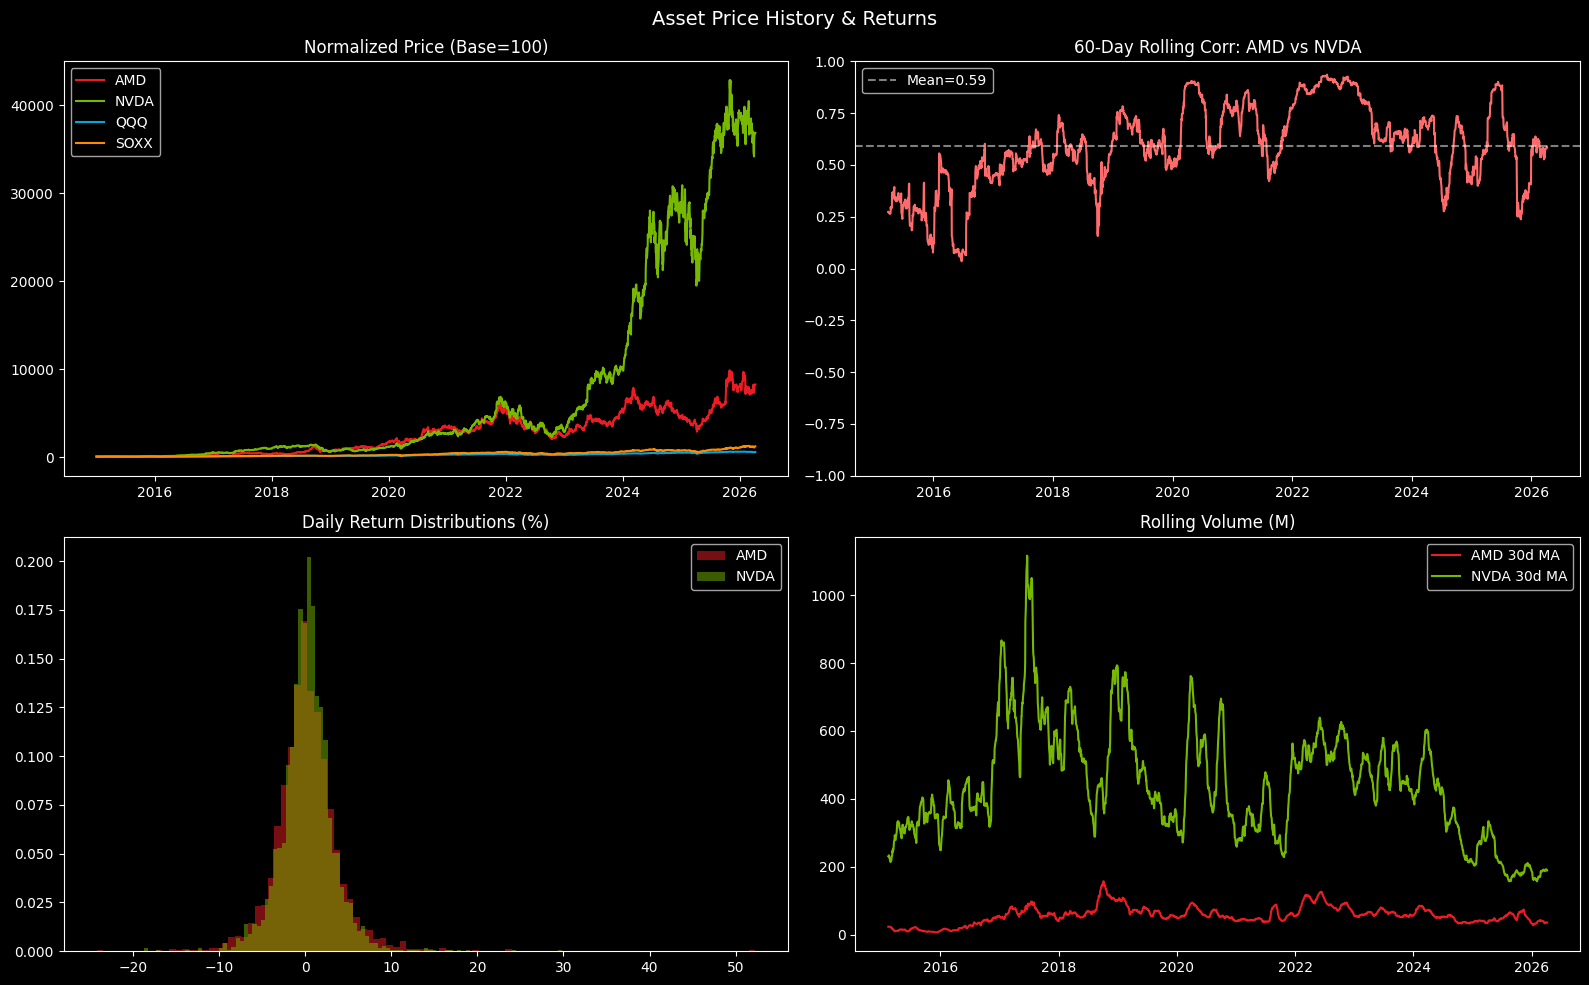

📊 EDA saved.


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Asset Price History & Returns', fontsize=14)

ax = axes[0,0]
for t in CONFIG['tickers']:
    s = price_data[t]['close'].loc[common_dates]
    ax.plot(s.index, s/s.iloc[0]*100, label=t, color=COLORS[t], lw=1.5)
ax.set_title('Normalized Price (Base=100)'); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax = axes[0,1]
r_amd  = price_data['AMD']['close'].pct_change().loc[common_dates]
r_nvda = price_data['NVDA']['close'].pct_change().loc[common_dates]
rc = r_amd.rolling(60).corr(r_nvda)
ax.plot(rc.index, rc, color='#FF6B6B', lw=1.5)
ax.axhline(rc.mean(), color='white', ls='--', alpha=0.5, label=f'Mean={rc.mean():.2f}')
ax.set_title('60-Day Rolling Corr: AMD vs NVDA'); ax.legend(); ax.set_ylim(-1,1)

ax = axes[1,0]
for t in ['AMD','NVDA']:
    r = price_data[t]['close'].pct_change().loc[common_dates].dropna()
    ax.hist(r*100, bins=100, alpha=0.5, label=t, color=COLORS[t], density=True)
ax.set_title('Daily Return Distributions (%)'); ax.legend()

ax = axes[1,1]
for t in ['AMD','NVDA']:
    v = price_data[t]['volume'].rolling(30).mean().loc[common_dates]
    ax.plot(v.index, v/1e6, label=f'{t} 30d MA', color=COLORS[t], lw=1.5)
ax.set_title('Rolling Volume (M)'); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('results/01_eda.png', dpi=150, bbox_inches='tight')
plt.show(); print('📊 EDA saved.')

## 3. 🔧 Feature Engineering

In [7]:
def engineer_features(ticker, price_data, common_dates):
    """
    Full feature set. Fixes vs original:
    - ema_12 / ema_26 created BEFORE being referenced
    - cross-ticker columns named consistently ({cross}_lag_*)
    - function no longer truncated mid-body
    """
    df = price_data[ticker].loc[common_dates].copy()

    # Returns
    for p in [1,3,5,10,21]:
        df[f'ret_{p}d'] = df['close'].pct_change(p)

    # Lagged returns
    for lag in [1,2,3,4,5,10]:
        df[f'lag_ret_{lag}'] = df['ret_1d'].shift(lag)

    # Moving averages
    for w in [5,10,12,20,26,50,200]:          # ← include 12 & 26 for EMA ratio
        df[f'ma_{w}']  = df['close'].rolling(w).mean()
        df[f'ema_{w}'] = df['close'].ewm(span=w, adjust=False).mean()

    # MA/EMA ratios (ema_12, ema_26 now guaranteed to exist)
    df['ma5_ma20_ratio']    = df['ma_5']   / df['ma_20']
    df['ma20_ma50_ratio']   = df['ma_20']  / df['ma_50']
    df['ma50_ma200_ratio']  = df['ma_50']  / df['ma_200']
    df['ema12_ema26_ratio'] = df['ema_12'] / df['ema_26']   # ← FIX: no conditional

    for w in [10,20,50]:
        df[f'price_vs_ma{w}'] = (df['close'] - df[f'ma_{w}']) / df[f'ma_{w}']

    # RSI
    for w in [7,14,28]:
        df[f'rsi_{w}'] = ta.momentum.RSIIndicator(close=df['close'], window=w).rsi()

    # MACD
    macd = ta.trend.MACD(close=df['close'])
    df['macd']        = macd.macd()
    df['macd_signal'] = macd.macd_signal()
    df['macd_hist']   = macd.macd_diff()
    df['macd_cross']  = np.sign(df['macd'] - df['macd_signal'])

    # Bollinger Bands
    bb = ta.volatility.BollingerBands(close=df['close'], window=20, window_dev=2)
    df['bb_high']  = bb.bollinger_hband()
    df['bb_low']   = bb.bollinger_lband()
    df['bb_mid']   = bb.bollinger_mavg()
    df['bb_width'] = (df['bb_high'] - df['bb_low']) / df['bb_mid']
    df['bb_pct']   = (df['close'] - df['bb_low']) / (df['bb_high'] - df['bb_low'])

    # ATR & volatility
    df['atr_14'] = ta.volatility.AverageTrueRange(
        high=df['high'], low=df['low'], close=df['close'], window=14
    ).average_true_range()
    for w in [5,10,20,60]:
        df[f'vol_{w}d'] = df['ret_1d'].rolling(w).std() * np.sqrt(252)
    df['vol_ratio_5_20'] = df['vol_5d'] / df['vol_20d']    # ← was truncated here

    # Stochastic
    stoch = ta.momentum.StochasticOscillator(high=df['high'], low=df['low'], close=df['close'])
    df['stoch_k'] = stoch.stoch()
    df['stoch_d'] = stoch.stoch_signal()

    # Volume
    df['vol_chg_1d']  = df['volume'].pct_change(1)
    df['vol_chg_5d']  = df['volume'].pct_change(5)
    df['vol_ma20']    = df['volume'].rolling(20).mean()
    df['vol_vs_ma20'] = df['volume'] / df['vol_ma20']
    df['obv']         = ta.volume.OnBalanceVolumeIndicator(
        close=df['close'], volume=df['volume']).on_balance_volume()
    df['vwap_ratio']  = df['close'] / ((df['high'] + df['low'] + df['close']) / 3)

    # Price range
    df['high_low_ratio'] = (df['high'] - df['low']) / df['close']
    df['close_open_ret'] = (df['close'] - df['open']) / df['open']
    df['gap']            = (df['open'] - df['close'].shift(1)) / df['close'].shift(1)

    # Cross-asset signals
    cross = 'NVDA' if ticker == 'AMD' else 'AMD'
    cross_ret = price_data[cross]['close'].pct_change().loc[common_dates]
    qqq_ret   = price_data['QQQ']['close'].pct_change().loc[common_dates]
    soxx_ret  = price_data['SOXX']['close'].pct_change().loc[common_dates]

    # ── FIX: use cross.lower() consistently (amd_lag_* for NVDA, nvda_lag_* for AMD)
    for lag in [1,2,3]:
        df[f'{cross.lower()}_lag_{lag}'] = cross_ret.shift(lag)
        df[f'qqq_lag_{lag}']             = qqq_ret.shift(lag)
        df[f'soxx_lag_{lag}']            = soxx_ret.shift(lag)

    df[f'{cross.lower()}_ret'] = cross_ret
    df['qqq_ret']  = qqq_ret
    df['soxx_ret'] = soxx_ret

    df[f'spread_vs_{cross.lower()}'] = df['ret_1d'] - cross_ret
    df['spread_vs_soxx'] = df['ret_1d'] - soxx_ret
    df['beta_vs_qqq'] = (
        df['ret_1d'].rolling(20).cov(qqq_ret) / qqq_ret.rolling(20).var()
    )

    # Calendar
    df['day_of_week']    = df.index.dayofweek
    df['day_of_month']   = df.index.day
    df['month']          = df.index.month
    df['quarter']        = df.index.quarter
    df['is_month_end']   = df.index.is_month_end.astype(int)
    df['is_month_start'] = df.index.is_month_start.astype(int)

    # Target
    future_ret       = df['close'].pct_change(1).shift(-1)
    df['target']     = (future_ret > 0).astype(int)
    df['target_ret'] = future_ret
    df['ticker']     = ticker

    return df


features = {}
for t in CONFIG['primary']:
    features[t] = engineer_features(t, price_data, common_dates)
    print(f'{t}: {features[t].shape[1]} features, {len(features[t])} rows')

# feat_cols defined HERE so FEATURE_COLS cell can use it
amd_feat = features['AMD']
feat_cols = [c for c in amd_feat.columns
             if c not in ['target','target_ret','ticker']]
print(f'\nTotal feature columns: {len(feat_cols)}')

AMD: 90 features, 2831 rows
NVDA: 90 features, 2831 rows

Total feature columns: 87


In [8]:
# ── FIX: only ONE time_split definition; safe preprocessing baked in ──────────
def time_split(df, train_r, val_r):
    """Chronological split. Drops rows missing target; ffill/bfill features."""
    df = df.sort_index().dropna(subset=['target']).copy()
    df = df.ffill().bfill()
    # Remove first 250 rows (unstable rolling indicators)
    if len(df) > 250:
        df = df.iloc[250:]
    n = len(df)
    if n == 0:
        raise ValueError('Dataset empty after preprocessing')
    i_train = int(n * train_r)
    i_val   = int(n * (train_r + val_r))
    return df.iloc[:i_train], df.iloc[i_train:i_val], df.iloc[i_val:]


splits = {}
for t in CONFIG['primary']:
    train, val, test = time_split(features[t], CONFIG['train_ratio'], CONFIG['val_ratio'])
    splits[t] = {'train': train, 'val': val, 'test': test}
    print(f'\n{t}: train={len(train):,} | val={len(val):,} | test={len(test):,}')
    print(f'  {train.index[0].date()} → train → {train.index[-1].date()}')
    print(f'  {val.index[0].date()}   → val   → {val.index[-1].date()}')
    print(f'  {test.index[0].date()}  → test  → {test.index[-1].date()}')
    print(f'  Up days (train): {train["target"].mean():.1%}')


AMD: train=1,806 | val=387 | test=388
  2015-12-30 → train → 2023-03-03
  2023-03-06   → val   → 2024-09-17
  2024-09-18  → test  → 2026-04-07
  Up days (train): 51.1%

NVDA: train=1,806 | val=387 | test=388
  2015-12-30 → train → 2023-03-03
  2023-03-06   → val   → 2024-09-17
  2024-09-18  → test  → 2026-04-07
  Up days (train): 54.4%


## 4. 🌲 Model A: XGBoost (Baseline)

In [9]:
# ── FIX: excluded cols built dynamically — no hard-coded ticker names ─────────
EXCLUDED_BASE = {
    'target', 'target_ret', 'ticker',
    'open', 'high', 'low', 'close', 'volume',
    # Concurrent (same-day) cross-asset returns leak T+0 into T+1 prediction
    'nvda_ret', 'amd_ret', 'qqq_ret', 'soxx_ret',
}

FEATURE_COLS = [c for c in feat_cols if c not in EXCLUDED_BASE]
print(f'XGBoost feature count: {len(FEATURE_COLS)}')
print('Sample:', FEATURE_COLS[:12])

XGBoost feature count: 79
Sample: ['ret_1d', 'ret_3d', 'ret_5d', 'ret_10d', 'ret_21d', 'lag_ret_1', 'lag_ret_2', 'lag_ret_3', 'lag_ret_4', 'lag_ret_5', 'lag_ret_10', 'ma_5']


In [10]:
def prepare_xy(df, feature_cols):
    # ── FIX: only select columns that actually exist in df ────────────────────
    available = [c for c in feature_cols if c in df.columns]
    missing   = [c for c in feature_cols if c not in df.columns]
    if missing:
        print(f'  ⚠️  Skipping {len(missing)} missing columns: {missing[:5]}')
    X = df[available].values
    y = df['target'].values
    return X, y, available


def train_xgboost(ticker, splits, feature_cols, tune=False):
    train = splits[ticker]['train']
    val   = splits[ticker]['val']

    X_train, y_train, used_cols = prepare_xy(train, feature_cols)
    X_val,   y_val,   _         = prepare_xy(val,   used_cols)

    scaler    = RobustScaler()
    Xtr_s     = scaler.fit_transform(X_train)
    Xval_s    = scaler.transform(X_val)

    if tune:
        param_dist = {
            'n_estimators': [200,300,500], 'max_depth': [3,4,5,6],
            'learning_rate': [0.01,0.05,0.1], 'subsample': [0.6,0.7,0.8],
            'colsample_bytree': [0.6,0.7,0.8], 'min_child_weight': [1,3,5],
            'reg_alpha': [0,0.1,0.5], 'reg_lambda': [1,2,5], 'gamma': [0,0.1,0.3],
        }
        base = xgb.XGBClassifier(objective='binary:logistic', eval_metric='auc',
                                  random_state=RANDOM_SEED, n_jobs=-1)
        search = RandomizedSearchCV(base, param_dist, n_iter=20, cv=3,
                                    scoring='roc_auc', random_state=RANDOM_SEED,
                                    n_jobs=-1, verbose=0)
        search.fit(Xtr_s, y_train, eval_set=[(Xval_s, y_val)], verbose=False)
        model = search.best_estimator_
        print(f'  Best params: {search.best_params_}')
    else:
        model = xgb.XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.7, min_child_weight=3,
            reg_alpha=0.1, reg_lambda=2, objective='binary:logistic',
            eval_metric='auc', random_state=RANDOM_SEED, n_jobs=-1
        )
        model.fit(Xtr_s, y_train, eval_set=[(Xval_s, y_val)], verbose=50)

    proba    = model.predict_proba(Xval_s)[:,1]
    val_auc  = roc_auc_score(y_val, proba)
    val_acc  = accuracy_score(y_val, (proba>0.5).astype(int))
    print(f'  {ticker} Val AUC={val_auc:.4f} | Acc={val_acc:.4f}')

    return {'model': model, 'scaler': scaler,        # ← FIX: complete return
            'val_auc': val_auc, 'used_cols': used_cols}


print('Training XGBoost …')
xgb_models = {}
for t in CONFIG['primary']:
    print(f'\n--- {t} ---')
    xgb_models[t] = train_xgboost(t, splits, FEATURE_COLS, tune=False)
print('\n✅ XGBoost done.')

Training XGBoost …

--- AMD ---
[0]	validation_0-auc:0.47677
[50]	validation_0-auc:0.53275
[100]	validation_0-auc:0.51993
[150]	validation_0-auc:0.52888
[200]	validation_0-auc:0.52604
[250]	validation_0-auc:0.51958
[299]	validation_0-auc:0.50761
  AMD Val AUC=0.5076 | Acc=0.5142

--- NVDA ---
  ⚠️  Skipping 4 missing columns: ['nvda_lag_1', 'nvda_lag_2', 'nvda_lag_3', 'spread_vs_nvda']
[0]	validation_0-auc:0.50303
[50]	validation_0-auc:0.52096
[100]	validation_0-auc:0.51336
[150]	validation_0-auc:0.51947
[200]	validation_0-auc:0.50809
[250]	validation_0-auc:0.49957
[299]	validation_0-auc:0.50387
  NVDA Val AUC=0.5039 | Acc=0.4755

✅ XGBoost done.


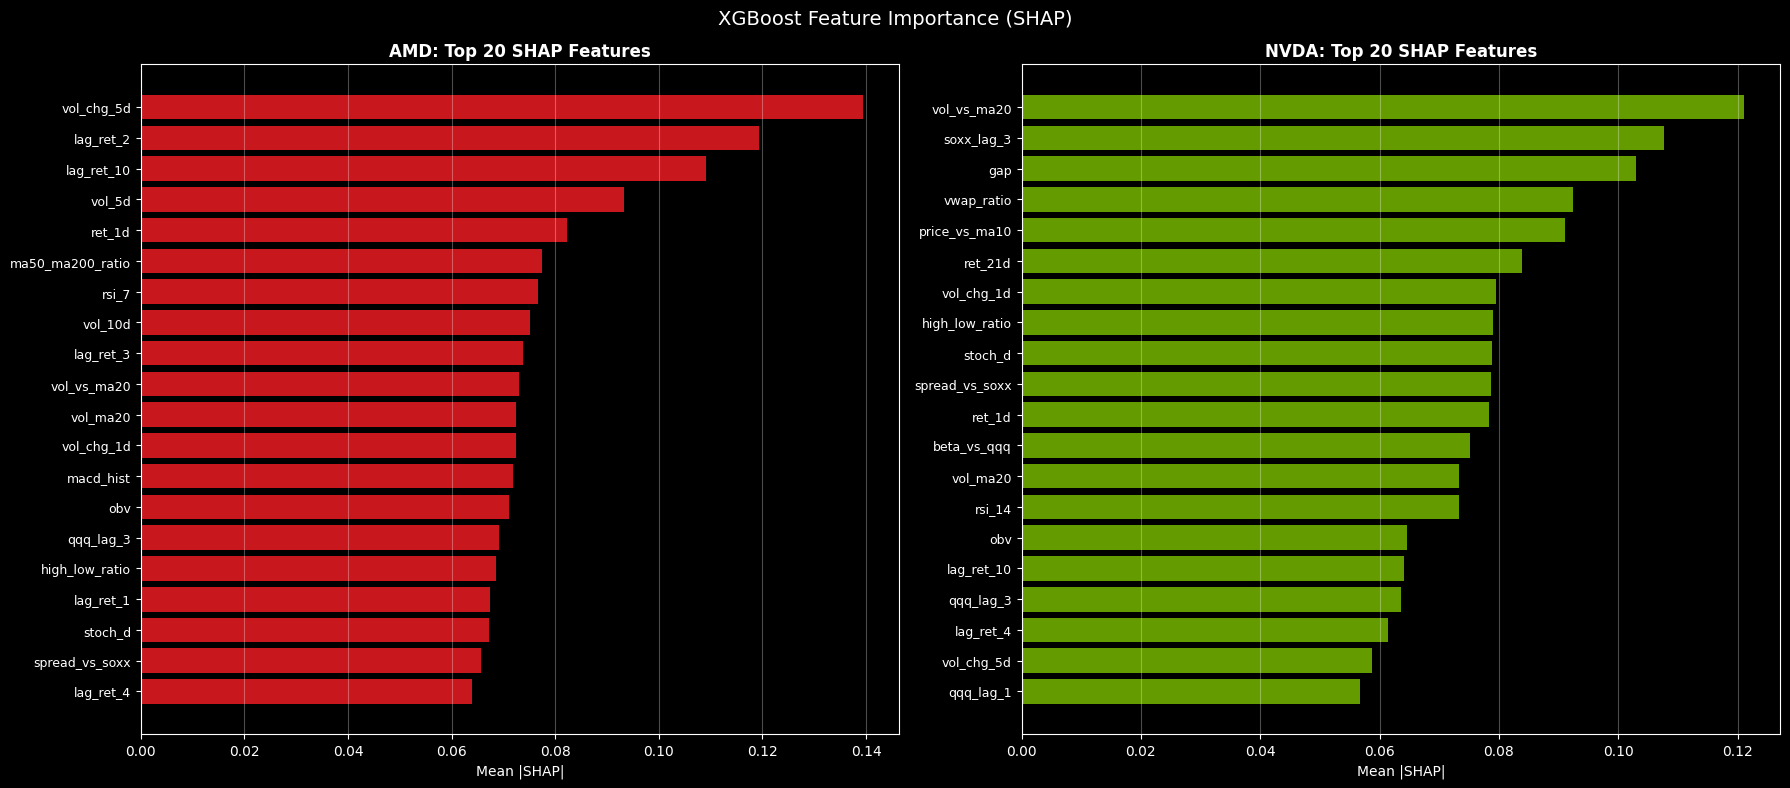

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for i, t in enumerate(CONFIG['primary']):
    ax     = axes[i]
    info   = xgb_models[t]
    model  = info['model']
    scaler = info['scaler']
    used   = info['used_cols']
    train  = splits[t]['train']

    X, _, _ = prepare_xy(train, used)
    Xs      = scaler.transform(X)

    explainer = shap.TreeExplainer(model)
    sv        = explainer.shap_values(Xs[:500])
    mean_sv   = np.abs(sv).mean(axis=0)
    top_idx   = np.argsort(mean_sv)[-20:][::-1]

    ax.barh(range(20), mean_sv[top_idx][::-1], color=COLORS[t], alpha=0.85)
    ax.set_yticks(range(20))
    ax.set_yticklabels([used[j] for j in top_idx][::-1], fontsize=9)
    ax.set_title(f'{t}: Top 20 SHAP Features', fontweight='bold')
    ax.set_xlabel('Mean |SHAP|'); ax.grid(axis='x', alpha=0.3)

plt.suptitle('XGBoost Feature Importance (SHAP)', fontsize=14)
plt.tight_layout()
plt.savefig('results/02_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 🤖 Model B: Temporal Fusion Transformer (TFT)

In [13]:
def prepare_tft_dataset(ticker, features, seq_length):
    df = features[ticker].dropna().copy()
    # TFT + GroupNormalizer expects a floating-point target, even for binary labels.
    df['target'] = df['target'].astype('float32')
    df['time_idx'] = np.arange(len(df))
    df['group']    = ticker

    n         = len(df)
    train_end = int(n * CONFIG['train_ratio'])
    val_end   = int(n * (CONFIG['train_ratio'] + CONFIG['val_ratio']))

    known_reals   = ['day_of_week','day_of_month','month','quarter',
                     'is_month_end','is_month_start']
    unknown_reals = ['ret_1d','ret_3d','ret_5d','rsi_14','macd_hist',
                     'bb_pct','vol_20d','vol_vs_ma20','vol_chg_1d',
                     'ma5_ma20_ratio','ma20_ma50_ratio','atr_14',
                     'stoch_k','stoch_d','beta_vs_qqq','bb_width',
                     'price_vs_ma10','price_vs_ma20',
                    ] + [c for c in df.columns if '_lag_' in c]
    unknown_reals = [c for c in unknown_reals if c in df.columns]

    dataset = TimeSeriesDataSet(
        df[df.time_idx <= train_end + seq_length],
        time_idx='time_idx', target='target', group_ids=['group'],
        min_encoder_length=seq_length//2, max_encoder_length=seq_length,
        min_prediction_length=1, max_prediction_length=1,
        static_categoricals=['group'],
        time_varying_known_reals=known_reals,
        time_varying_unknown_reals=unknown_reals,
        target_normalizer=GroupNormalizer(groups=['group'], transformation='softplus'),
        add_relative_time_idx=True, add_target_scales=True,
        add_encoder_length=True, allow_missing_timesteps=True,
    )
    return dataset, train_end, val_end, df


print('Preparing TFT datasets …')
tft_datasets = {}
for t in CONFIG['primary']:
    ds, te, ve, df_full = prepare_tft_dataset(t, features, CONFIG['seq_length'])
    tft_datasets[t] = {'dataset': ds, 'train_end': te, 'val_end': ve, 'df_full': df_full}
    print(f'  {t}: {len(ds)} training samples')

Preparing TFT datasets …
  AMD: 1902 training samples
  NVDA: 1902 training samples


In [17]:
def build_and_train_tft(ticker, tft_datasets, max_epochs=50, batch_size=64):
    info      = tft_datasets[ticker]
    train_ds  = info['dataset']
    train_end = info['train_end']
    val_end   = info['val_end']
    df_full   = info['df_full']

    val_ds = TimeSeriesDataSet.from_dataset(
        train_ds, df_full[df_full.time_idx <= val_end],
        min_prediction_idx=train_end+1, stop_randomization=True
    )
    train_loader = train_ds.to_dataloader(train=True,  batch_size=batch_size, num_workers=0)
    val_loader   = val_ds.to_dataloader(  train=False, batch_size=batch_size, num_workers=0)

    tft = TemporalFusionTransformer.from_dataset(
        train_ds, learning_rate=1e-3, hidden_size=64,
        attention_head_size=4, dropout=0.2, hidden_continuous_size=32,
        output_size=7, loss=QuantileLoss(),
        log_interval=10, reduce_on_plateau_patience=5, lstm_layers=2,
    )
    print(f'  {ticker} TFT params: {tft.size()/1e3:.1f}K')

    trainer = pl.Trainer(
        max_epochs=max_epochs, accelerator='auto',
        gradient_clip_val=0.1, logger=False, enable_progress_bar=True,
        callbacks=[
            pl.callbacks.EarlyStopping(monitor='val_loss', patience=10, mode='min'),
            pl.callbacks.ModelCheckpoint(
                dirpath='models/', filename=f'tft_{ticker.lower()}',
                monitor='val_loss', mode='min'),
        ],
    )
    trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

    best_path = trainer.checkpoint_callback.best_model_path
    best_tft  = TemporalFusionTransformer.load_from_checkpoint(best_path)
    return {'model': best_tft, 'train_ds': train_ds, 'val_ds': val_ds,
            'val_loader': val_loader, 'val_end': val_end,
            'df_full': df_full}          # ← FIX: complete return statement


print('Training TFT models (may take several minutes) …')
tft_models = {}
for t in CONFIG['primary']:
    print(f'\n=== {t} TFT ===')
    tft_models[t] = build_and_train_tft(t, tft_datasets, max_epochs=50)
print('\n✅ TFT training complete.')

Training TFT models (may take several minutes) …

=== AMD TFT ===


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


  AMD TFT params: 615.1K


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  2.4 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 20.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  271 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 49.3 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 66.6 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 66.6 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    455 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 615 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 615 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 819                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  2.4 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 20.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  271 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 49.3 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 66.6 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 66.6 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    455 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 615 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 615 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 819                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=50` reached.



✅ TFT training complete.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


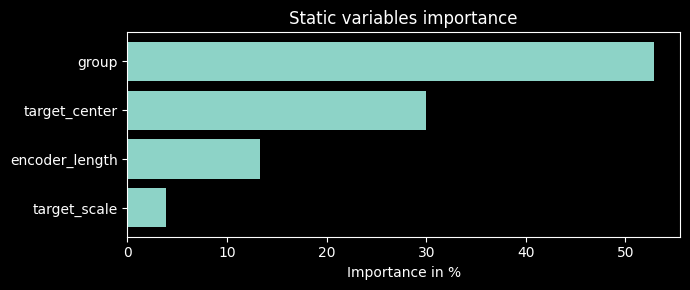

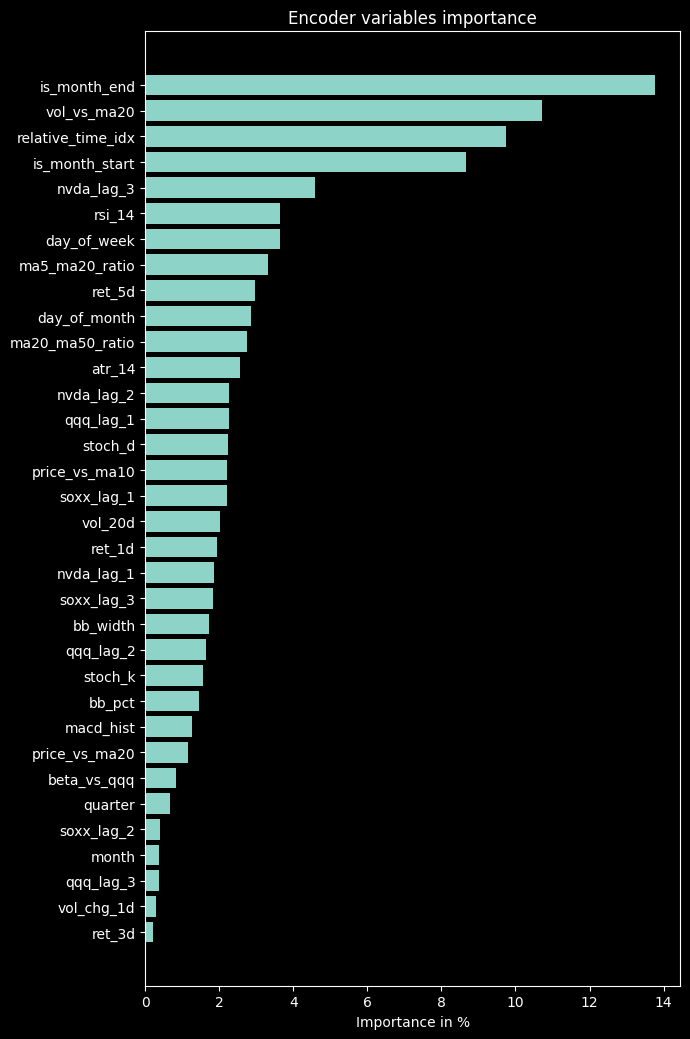

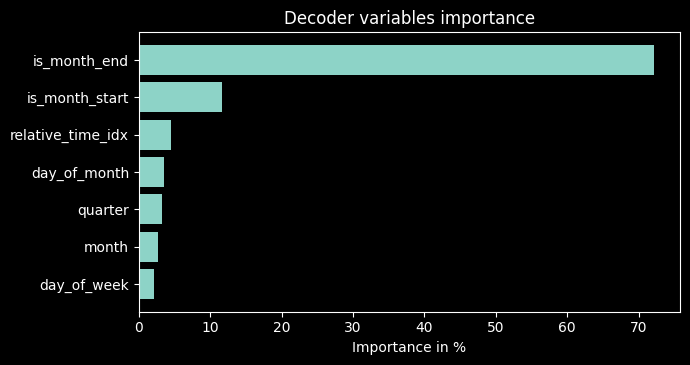

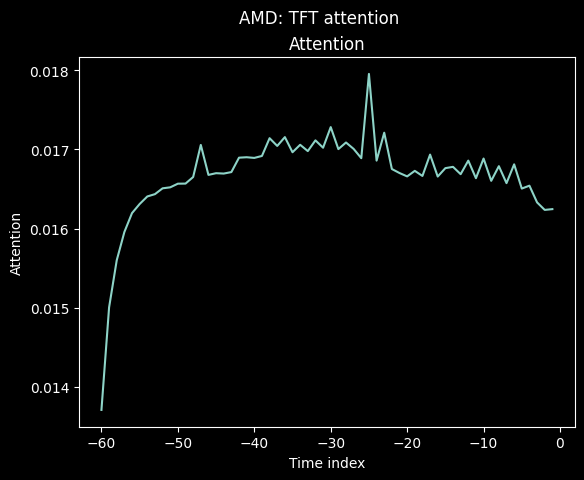

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


AMD TFT attention plotted.


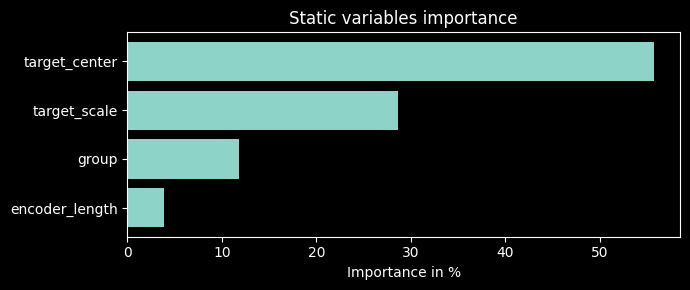

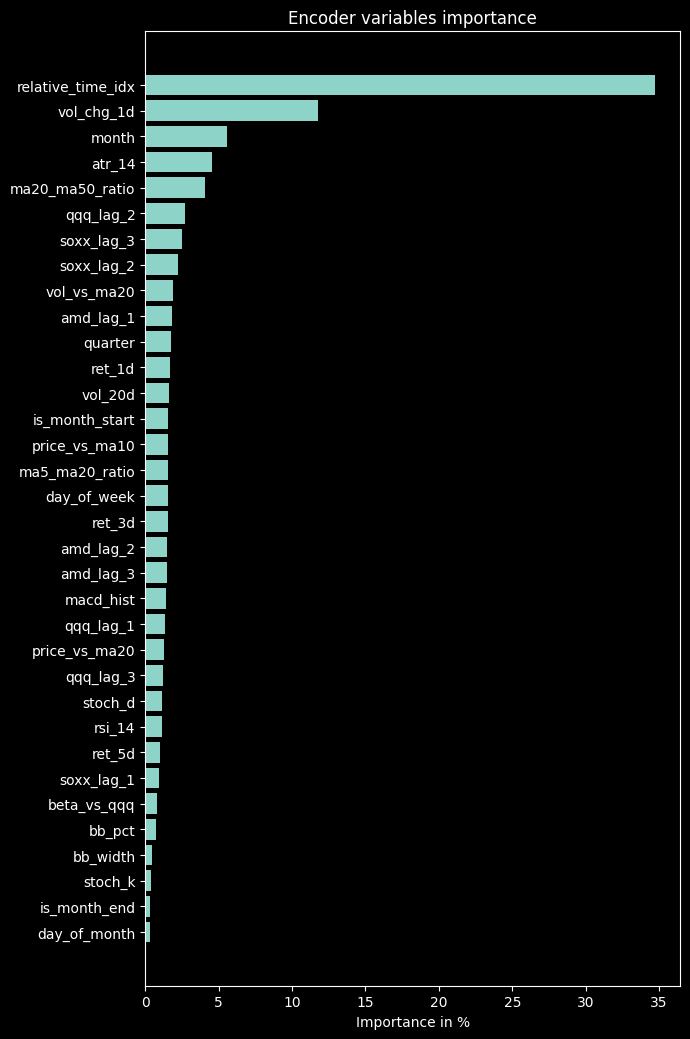

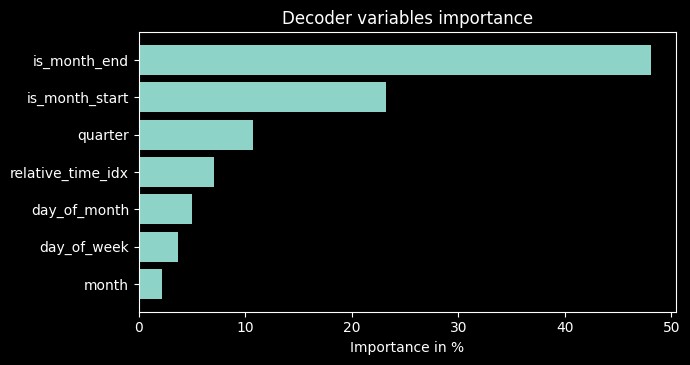

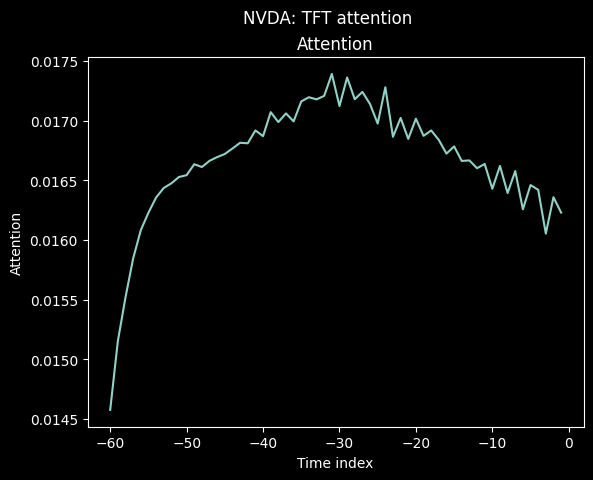

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

NVDA TFT attention plotted.


In [20]:
for t in CONFIG['primary']:
    best_tft   = tft_models[t]['model']
    val_loader = tft_models[t]['val_loader']
    raw_preds  = best_tft.predict(val_loader, mode='raw', return_x=True)
    interp     = best_tft.interpret_output(raw_preds[0], reduction='sum')
    plots      = best_tft.plot_interpretation(interp)

    # pytorch-forecasting may return either a dict of figures or a single figure.
    if isinstance(plots, dict):
        for name, fig in plots.items():
            if hasattr(fig, 'suptitle'):
                fig.suptitle(f'{t}: TFT {name}', fontsize=12)
            plt.figure(fig.number)
            plt.savefig(f"results/03_tft_{name}_{t}.png", dpi=130, bbox_inches='tight')
            plt.show()
    else:
        fig = plots
        if hasattr(fig, 'suptitle'):
            fig.suptitle(f'{t}: TFT Variable Importance & Attention', fontsize=12)
        plt.figure(fig.number)
        plt.savefig(f'results/03_tft_attention_{t}.png', dpi=130, bbox_inches='tight')
        plt.show()

    print(f'{t} TFT attention plotted.')

## 5b. 🔁 Model B2: LSTM (Paper Replication — Moghar & Hamiche 2020)

Replicating the 4-layer LSTM architecture from the reference paper, adapted for AMD/NVDA
with direction classification instead of price regression.

In [21]:
# ── LSTM implementation (paper-inspired, classification variant) ──────────────
class LSTMClassifier(nn.Module):
    """
    4-layer stacked LSTM with Dropout, matching Moghar & Hamiche (2020) architecture.
    Input:  (batch, seq_len, n_features)
    Output: (batch, 1) — probability of upward movement
    """
    def __init__(self, input_size, hidden_size=96, num_layers=4, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = self.dropout(out[:, -1, :])   # Take last timestep
        return self.sigmoid(self.fc(out))


def make_sequences(df, feature_cols, seq_len):
    """Convert flat DataFrame into (X_sequences, y) arrays."""
    available = [c for c in feature_cols if c in df.columns]
    vals = df[available].values
    targ = df['target'].values
    X, y = [], []
    for i in range(seq_len, len(vals)):
        X.append(vals[i-seq_len:i])
        y.append(targ[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def train_lstm(ticker, splits, feature_cols, seq_len=30,
               epochs=50, lr=1e-3, batch_size=64):
    train_df = splits[ticker]['train']
    val_df   = splits[ticker]['val']

    X_train, y_train = make_sequences(train_df, feature_cols, seq_len)
    X_val,   y_val   = make_sequences(val_df,   feature_cols, seq_len)

    # Normalize per-feature across training set
    mu     = X_train.reshape(-1, X_train.shape[-1]).mean(0)
    sigma  = X_train.reshape(-1, X_train.shape[-1]).std(0) + 1e-8
    X_train = (X_train - mu) / sigma
    X_val   = (X_val   - mu) / sigma

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model  = LSTMClassifier(input_size=X_train.shape[-1]).to(device)
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    crit   = nn.BCELoss()

    Xt = torch.tensor(X_train).to(device)
    yt = torch.tensor(y_train).unsqueeze(1).to(device)
    Xv = torch.tensor(X_val).to(device)
    yv = torch.tensor(y_val).unsqueeze(1).to(device)

    best_auc, best_state = 0.0, None
    history = []

    for epoch in range(1, epochs+1):
        model.train()
        idx   = torch.randperm(len(Xt))
        total_loss = 0.0
        for b in range(0, len(Xt), batch_size):
            xb = Xt[idx[b:b+batch_size]]
            yb = yt[idx[b:b+batch_size]]
            opt.zero_grad()
            pred = model(xb)
            loss = crit(pred, yb)
            loss.backward(); opt.step()
            total_loss += loss.item()

        model.eval()
        with torch.no_grad():
            val_pred = model(Xv).cpu().numpy().squeeze()
        val_auc = roc_auc_score(y_val, val_pred)
        history.append({'epoch': epoch, 'loss': total_loss, 'val_auc': val_auc})

        if val_auc > best_auc:
            best_auc   = val_auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0:
            print(f'  Epoch {epoch:3d}/{epochs} | loss={total_loss:.4f} | val_auc={val_auc:.4f}')

    model.load_state_dict(best_state)
    print(f'  {ticker} LSTM best val AUC: {best_auc:.4f}')
    return {'model': model, 'mu': mu, 'sigma': sigma, 'seq_len': seq_len,
            'feature_cols': [c for c in feature_cols if c in train_df.columns],
            'history': history, 'best_auc': best_auc, 'device': device}


LSTM_FEATURE_COLS = [c for c in FEATURE_COLS
                     if c not in ['day_of_week','day_of_month','month',
                                  'quarter','is_month_end','is_month_start']]

print('Training LSTM models …')
lstm_models = {}
for t in CONFIG['primary']:
    print(f'\n--- {t} ---')
    lstm_models[t] = train_lstm(t, splits, LSTM_FEATURE_COLS, seq_len=30, epochs=50)
print('\n✅ LSTM training complete.')

Training LSTM models …

--- AMD ---
  Epoch  10/50 | loss=18.7896 | val_auc=0.5613
  Epoch  20/50 | loss=17.3082 | val_auc=0.5510
  Epoch  30/50 | loss=15.4873 | val_auc=0.5083
  Epoch  40/50 | loss=13.6518 | val_auc=0.5163
  Epoch  50/50 | loss=11.0193 | val_auc=0.5245
  AMD LSTM best val AUC: 0.5821

--- NVDA ---
  Epoch  10/50 | loss=18.7659 | val_auc=0.5127
  Epoch  20/50 | loss=17.3243 | val_auc=0.5109
  Epoch  30/50 | loss=16.2710 | val_auc=0.5168
  Epoch  40/50 | loss=14.7322 | val_auc=0.5272
  Epoch  50/50 | loss=12.4342 | val_auc=0.5242
  NVDA LSTM best val AUC: 0.5541

✅ LSTM training complete.


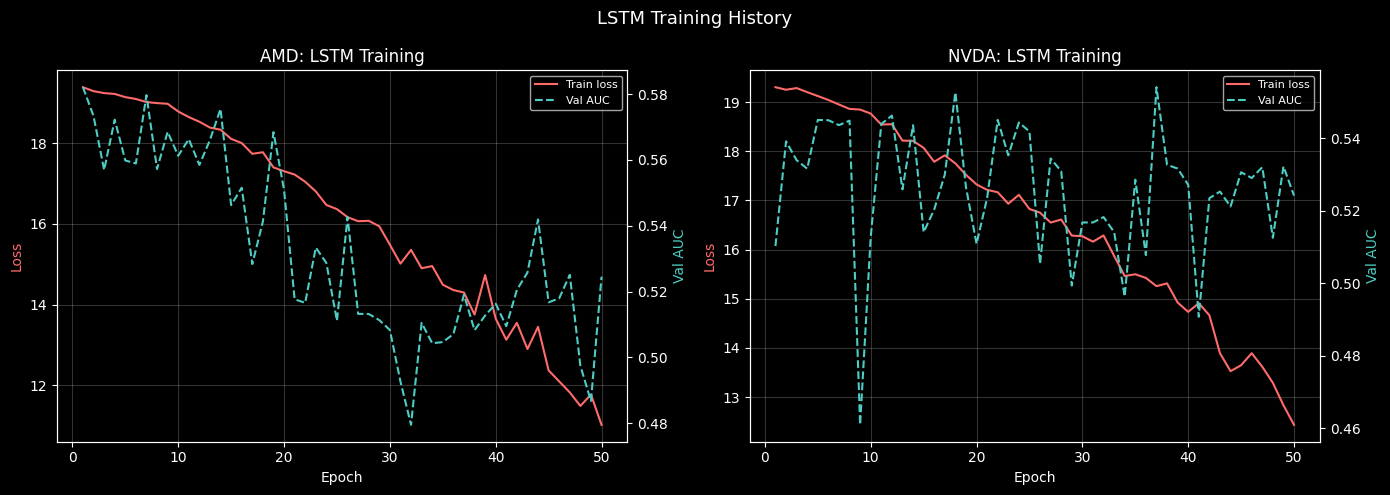

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM Training History', fontsize=13)
for ax, t in zip(axes, CONFIG['primary']):
    hist = pd.DataFrame(lstm_models[t]['history'])
    ax2  = ax.twinx()
    ax.plot(hist['epoch'], hist['loss'],   color='#FF6B6B', label='Train loss', lw=1.5)
    ax2.plot(hist['epoch'], hist['val_auc'], color='#4ECDC4', label='Val AUC', lw=1.5, ls='--')
    ax.set_title(f'{t}: LSTM Training'); ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss', color='#FF6B6B'); ax2.set_ylabel('Val AUC', color='#4ECDC4')
    lines1, lbl1 = ax.get_legend_handles_labels()
    lines2, lbl2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, lbl1+lbl2, fontsize=8)
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('results/04_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 🔀 Model C: Hybrid Stacked Ensemble

In [25]:
def get_xgb_predictions(ticker, xgb_models, splits, split_name='test'):
    info   = xgb_models[ticker]
    model  = info['model']
    scaler = info['scaler']
    used   = info['used_cols']
    df     = splits[ticker][split_name]
    X, _,_ = prepare_xy(df, used)
    return model.predict_proba(scaler.transform(X))[:,1]


def get_lstm_predictions(ticker, lstm_models, splits, split_name='test'):
    info    = lstm_models[ticker]
    model   = info['model']
    mu, sigma = info['mu'], info['sigma']
    seq_len = info['seq_len']
    fcols   = info['feature_cols']
    device  = info['device']

    df = splits[ticker][split_name]
    X, y = make_sequences(df, fcols, seq_len)
    X    = (X - mu) / sigma
    Xt   = torch.tensor(X).to(device)
    model.eval()
    with torch.no_grad():
        proba = model(Xt).cpu().numpy().squeeze()
    return proba, y


def _extract_tft_point_prediction(preds):
    """Convert TFT prediction tensor/array to 1D point predictions."""
    # `TemporalFusionTransformer.predict` output shape varies by version/loss setup.
    if isinstance(preds, torch.Tensor):
        arr = preds.detach().cpu().numpy()
    else:
        arr = np.asarray(preds)

    if arr.ndim == 1:
        out = arr
    elif arr.ndim == 2:
        # Common case for one-step forecasting: [n_samples, 1]
        out = arr[:, 0]
    elif arr.ndim == 3:
        # [n_samples, prediction_length, n_outputs/quantiles]
        if arr.shape[2] > 1:
            out = arr[:, 0, arr.shape[2] // 2]
        else:
            out = arr[:, 0, 0]
    else:
        raise ValueError(f'Unexpected TFT prediction shape: {arr.shape}')

    return np.asarray(out, dtype=np.float32).reshape(-1)


def get_tft_predictions(ticker, tft_models, split_name='test'):
    info     = tft_models[ticker]
    model    = info['model']
    train_ds = info['train_ds']
    df_full  = info['df_full']
    n        = len(df_full)
    cutoffs  = {
        'val':  (int(n*CONFIG['train_ratio']),
                 int(n*(CONFIG['train_ratio']+CONFIG['val_ratio']))),
        'test': (int(n*(CONFIG['train_ratio']+CONFIG['val_ratio'])), n),
    }
    start, end = cutoffs[split_name]
    split_ds = TimeSeriesDataSet.from_dataset(
        train_ds, df_full[df_full.time_idx <= end],
        min_prediction_idx=start, stop_randomization=True)
    loader = split_ds.to_dataloader(train=False, batch_size=128, num_workers=0)
    preds  = model.predict(loader)
    point_preds = _extract_tft_point_prediction(preds)

    # Target is binary (0/1) cast to float for TFT; clip to probability range.
    return np.clip(point_preds, 0.0, 1.0)


print('Prediction helpers defined.')

Prediction helpers defined.


In [26]:
def build_stacking_ensemble(ticker, xgb_models, tft_models, lstm_models, splits):
    xgb_val  = get_xgb_predictions(ticker, xgb_models, splits, 'val')
    tft_val  = get_tft_predictions(ticker, tft_models, 'val')
    lstm_val_proba, _ = get_lstm_predictions(ticker, lstm_models, splits, 'val')

    min_len  = min(len(xgb_val), len(tft_val), len(lstm_val_proba))
    xgb_val  = xgb_val[-min_len:]
    tft_val  = tft_val[-min_len:]
    lstm_val = lstm_val_proba[-min_len:]
    y_val    = splits[ticker]['val']['target'].values[-min_len:]

    X_meta = np.column_stack([
        xgb_val, tft_val, lstm_val,
        (xgb_val+tft_val+lstm_val)/3,
        np.abs(xgb_val-tft_val),
        np.abs(xgb_val-lstm_val),
        np.maximum(xgb_val, np.maximum(tft_val, lstm_val)),
    ])

    lr_meta  = LogisticRegression(C=1.0, max_iter=500, random_state=RANDOM_SEED)
    lgb_meta = lgb.LGBMClassifier(n_estimators=100, max_depth=3,
                                   learning_rate=0.05, random_state=RANDOM_SEED, verbose=-1)
    lr_meta.fit(X_meta, y_val)
    lgb_meta.fit(X_meta, y_val)

    ens = 0.5*lr_meta.predict_proba(X_meta)[:,1] + 0.5*lgb_meta.predict_proba(X_meta)[:,1]
    val_auc = roc_auc_score(y_val, ens)
    print(f'  {ticker} Stacking val AUC: {val_auc:.4f}')
    return {'lr_meta': lr_meta, 'lgb_meta': lgb_meta,
            'val_auc': val_auc, 'min_len': min_len}


print('Building stacking ensembles …')
hybrid_stacking = {}
for t in CONFIG['primary']:
    print(f'\n--- {t} ---')
    hybrid_stacking[t] = build_stacking_ensemble(
        t, xgb_models, tft_models, lstm_models, splits)
print('\n✅ Stacking ensembles built.')

Building stacking ensembles …

--- AMD ---


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False


  AMD Stacking val AUC: 0.8268

--- NVDA ---


TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


  NVDA Stacking val AUC: 0.8628

✅ Stacking ensembles built.


## 7. 📏 Evaluation & Comparison

In [27]:
def evaluate_model(y_true, y_proba, name, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'model':     name,
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_true, y_proba),
    }


all_results = {}

for t in CONFIG['primary']:
    print(f'\n=== {t} Test Set Evaluation ===')
    test_df   = splits[t]['test']
    y_test    = test_df['target'].values
    results   = []

    # Model A: XGBoost
    xgb_proba = get_xgb_predictions(t, xgb_models, splits, 'test')
    results.append(evaluate_model(y_test[:len(xgb_proba)], xgb_proba, 'XGBoost'))

    # Model B: TFT
    tft_proba = get_tft_predictions(t, tft_models, 'test')
    n_tft     = min(len(y_test), len(tft_proba))
    results.append(evaluate_model(y_test[-n_tft:], tft_proba[-n_tft:], 'TFT'))

    # Model B2: LSTM
    lstm_proba, lstm_y = get_lstm_predictions(t, lstm_models, splits, 'test')
    results.append(evaluate_model(lstm_y, lstm_proba, 'LSTM'))

    # Model C: Hybrid Stacking
    min_len   = min(len(xgb_proba), len(tft_proba), len(lstm_proba), len(y_test))
    xgb_t     = xgb_proba[-min_len:]
    tft_t     = tft_proba[-min_len:]
    lstm_t    = lstm_proba[-min_len:]
    y_t       = y_test[-min_len:]

    X_meta_test = np.column_stack([
        xgb_t, tft_t, lstm_t,
        (xgb_t+tft_t+lstm_t)/3,
        np.abs(xgb_t-tft_t),
        np.abs(xgb_t-lstm_t),
        np.maximum(xgb_t, np.maximum(tft_t, lstm_t)),
    ])
    hs       = hybrid_stacking[t]
    lr_p     = hs['lr_meta'].predict_proba(X_meta_test)[:,1]
    lgb_p    = hs['lgb_meta'].predict_proba(X_meta_test)[:,1]
    stk_p    = 0.5*lr_p + 0.5*lgb_p
    results.append(evaluate_model(y_t, stk_p, 'Hybrid (Stacking)'))

    rdf = pd.DataFrame(results).set_index('model')
    print(rdf.round(4).to_string())

    all_results[t] = {                          # ← FIX: complete dict
        'df': rdf,
        'probas': {
            'XGBoost':           (y_test[:len(xgb_proba)], xgb_proba),
            'TFT':               (y_test[-n_tft:],         tft_proba[-n_tft:]),
            'LSTM':              (lstm_y,                  lstm_proba),
            'Hybrid (Stacking)': (y_t,                     stk_p),
        },
    }


=== AMD Test Set Evaluation ===


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


                   accuracy  precision  recall      f1  roc_auc
model                                                          
XGBoost              0.4948     0.5192  0.2700  0.3553   0.5023
TFT                  0.4845     0.0000  0.0000  0.0000   0.5728
LSTM                 0.4916     0.5085  0.1639  0.2479   0.4987
Hybrid (Stacking)    0.4609     0.4734  0.4863  0.4798   0.4605

=== NVDA Test Set Evaluation ===


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


                   accuracy  precision  recall      f1  roc_auc
model                                                          
XGBoost              0.4691     0.5109  0.2260  0.3133   0.5190
TFT                  0.4639     0.0000  0.0000  0.0000   0.5268
LSTM                 0.4860     0.6429  0.0479  0.0891   0.4929
Hybrid (Stacking)    0.5307     0.5325  0.8723  0.6613   0.4954


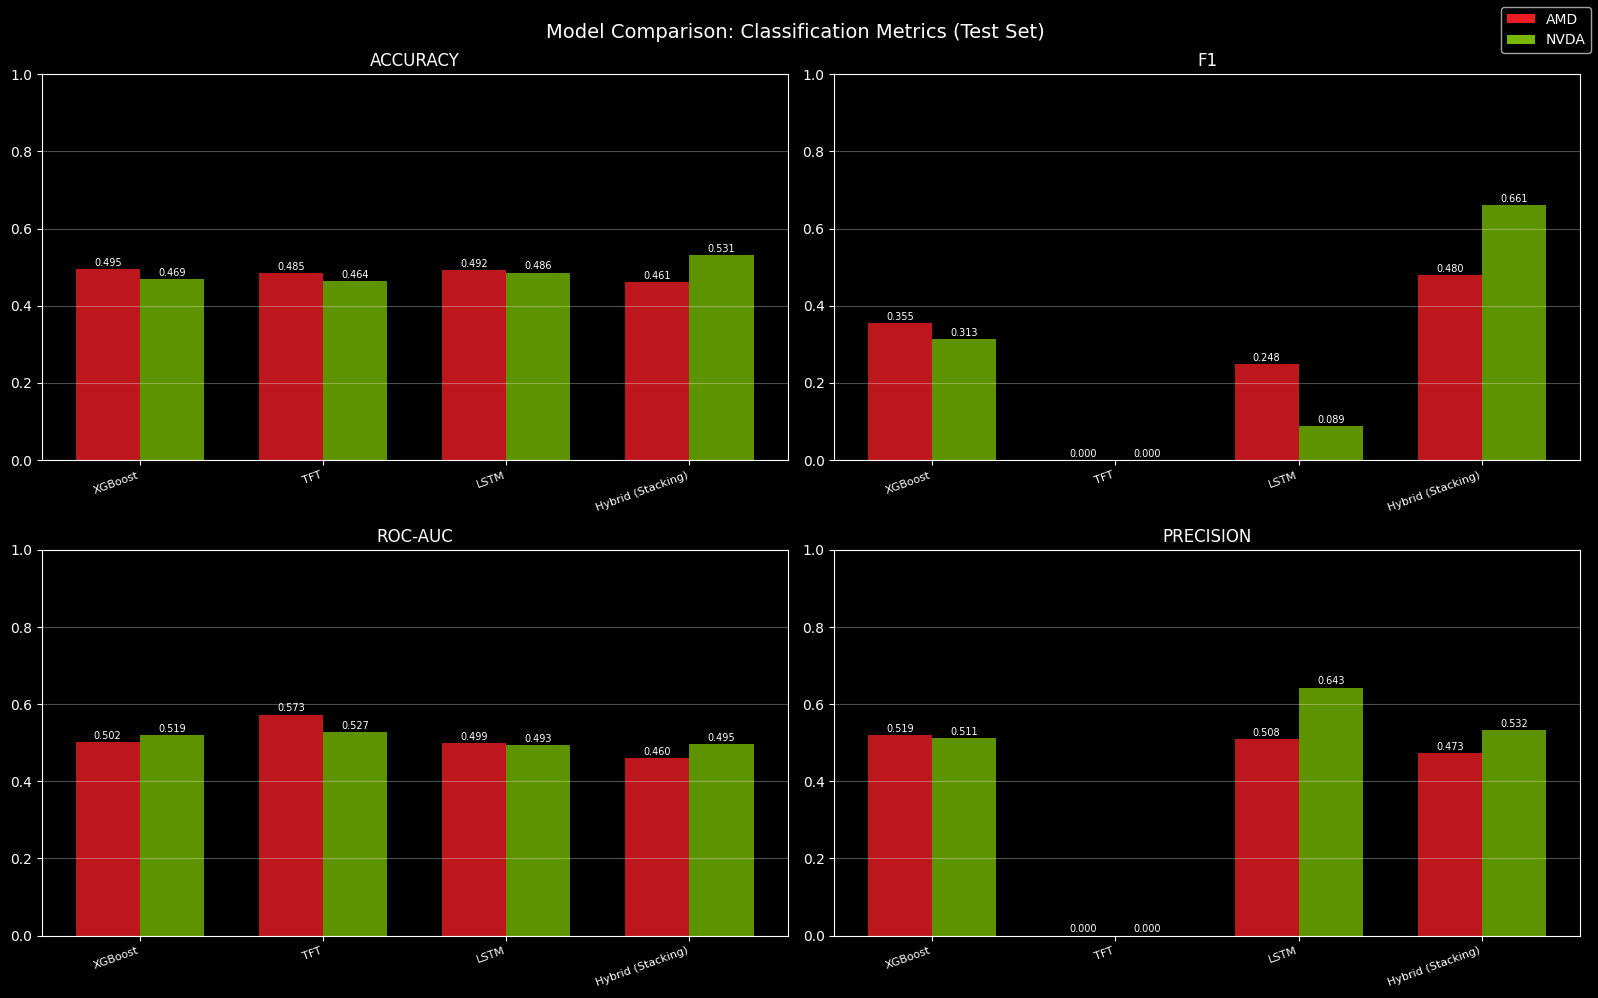

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Model Comparison: Classification Metrics (Test Set)', fontsize=14)
metrics = ['accuracy','f1','roc_auc','precision']

for idx, (ax, metric) in enumerate(zip(axes.flat, metrics)):
    for ti, t in enumerate(CONFIG['primary']):
        df   = all_results[t]['df']
        vals = df[metric].values
        mods = df.index.tolist()
        x    = np.arange(len(mods)) + ti*0.35
        bars = ax.bar(x, vals, 0.35, label=t if idx==0 else '',
                      color=COLORS[t], alpha=0.8)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7)
    ax.set_title(metric.upper().replace('_','-'))
    ax.set_xticks(np.arange(len(mods))+0.175)
    ax.set_xticklabels(mods, rotation=20, ha='right', fontsize=8)
    ax.set_ylim(0,1); ax.grid(axis='y', alpha=0.3)

handles = [plt.Rectangle((0,0),1,1,fc=COLORS[t]) for t in CONFIG['primary']]
fig.legend(handles, CONFIG['primary'], loc='upper right')
plt.tight_layout()
plt.savefig('results/05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 💰 Trading Simulation & Backtesting

In [29]:
def run_backtest(y_true, y_proba, actual_rets, name,
                 threshold=CONFIG['threshold'], tc=CONFIG['transaction_cost']):
    signals = (y_proba >= threshold).astype(int)
    cost    = np.abs(np.diff(signals, prepend=0)) * tc
    strat   = signals * actual_rets - cost
    bh      = actual_rets

    def sharpe(r):
        return (r.mean()/r.std())*np.sqrt(252) if r.std()>0 else 0
    def maxdd(r):
        cum = (1+r).cumprod()
        return ((cum - cum.cummax())/cum.cummax()).min()
    def calmar(r):
        ann = (1+r).prod()**(252/max(len(r),1))-1
        mdd = abs(maxdd(r))
        return ann/mdd if mdd>0 else 0

    s_s = pd.Series(strat); b_s = pd.Series(bh)
    cum = (1+s_s).cumprod(); cum_bh = (1+b_s).cumprod()
    return {
        'model': name, 'sharpe': sharpe(s_s), 'bh_sharpe': sharpe(b_s),
        'max_drawdown': maxdd(s_s), 'calmar': calmar(s_s),
        'cum_return': cum.iloc[-1]-1, 'bh_cum_return': cum_bh.iloc[-1]-1,
        'win_rate': (strat>0).mean(), 'trade_count': signals.sum(),
        'cum_returns': cum.values, 'cum_bh': cum_bh.values,
    }


backtest_results = {t: [] for t in CONFIG['primary']}

for t in CONFIG['primary']:
    for name, (y_t, y_p) in all_results[t]['probas'].items():
        actual = splits[t]['test']['target_ret'].values
        n      = min(len(y_p), len(actual))
        bt     = run_backtest(y_t[-n:], y_p[-n:], actual[-n:], name)
        backtest_results[t].append(bt)

# ── FIX: complete print loop (was truncated at `for`) ─────────────────────────
for t in CONFIG['primary']:
    print(f'\n=== {t} Backtest ===')
    rows = []
    for bt in backtest_results[t]:
        rows.append({
            'Model':   bt['model'],    'Sharpe':   f"{bt['sharpe']:.3f}",
            'MaxDD':   f"{bt['max_drawdown']:.2%}", 'Calmar':  f"{bt['calmar']:.3f}",
            'CumRet':  f"{bt['cum_return']:.2%}",   'BH_Ret':  f"{bt['bh_cum_return']:.2%}",
            'WinRate': f"{bt['win_rate']:.2%}",     'Trades':  bt['trade_count'],
        })
    print(pd.DataFrame(rows).set_index('Model').to_string())


=== AMD Backtest ===
                   Sharpe    MaxDD  Calmar   CumRet  BH_Ret WinRate  Trades
Model                                                                      
XGBoost            -0.559  -27.66%  -0.398  -16.45%  50.31%   8.25%      69
TFT                 0.000    0.00%   0.000    0.00%  50.31%   0.00%       0
LSTM                0.000    0.00%   0.000    0.00%  49.99%   0.00%       0
Hybrid (Stacking)  -1.333  -50.95%  -0.638  -42.82%  49.99%  14.53%     114

=== NVDA Backtest ===
                  Sharpe    MaxDD Calmar  CumRet  BH_Ret WinRate  Trades
Model                                                                   
XGBoost            0.305  -13.93%  0.267   5.78%  57.57%   7.73%      58
TFT                0.000    0.00%  0.000   0.00%  57.57%   0.00%       0
LSTM               0.451   -5.26%  0.529   3.98%  28.20%   1.40%       7
Hybrid (Stacking)  0.469  -27.40%  0.403  16.04%  28.20%  32.12%     220


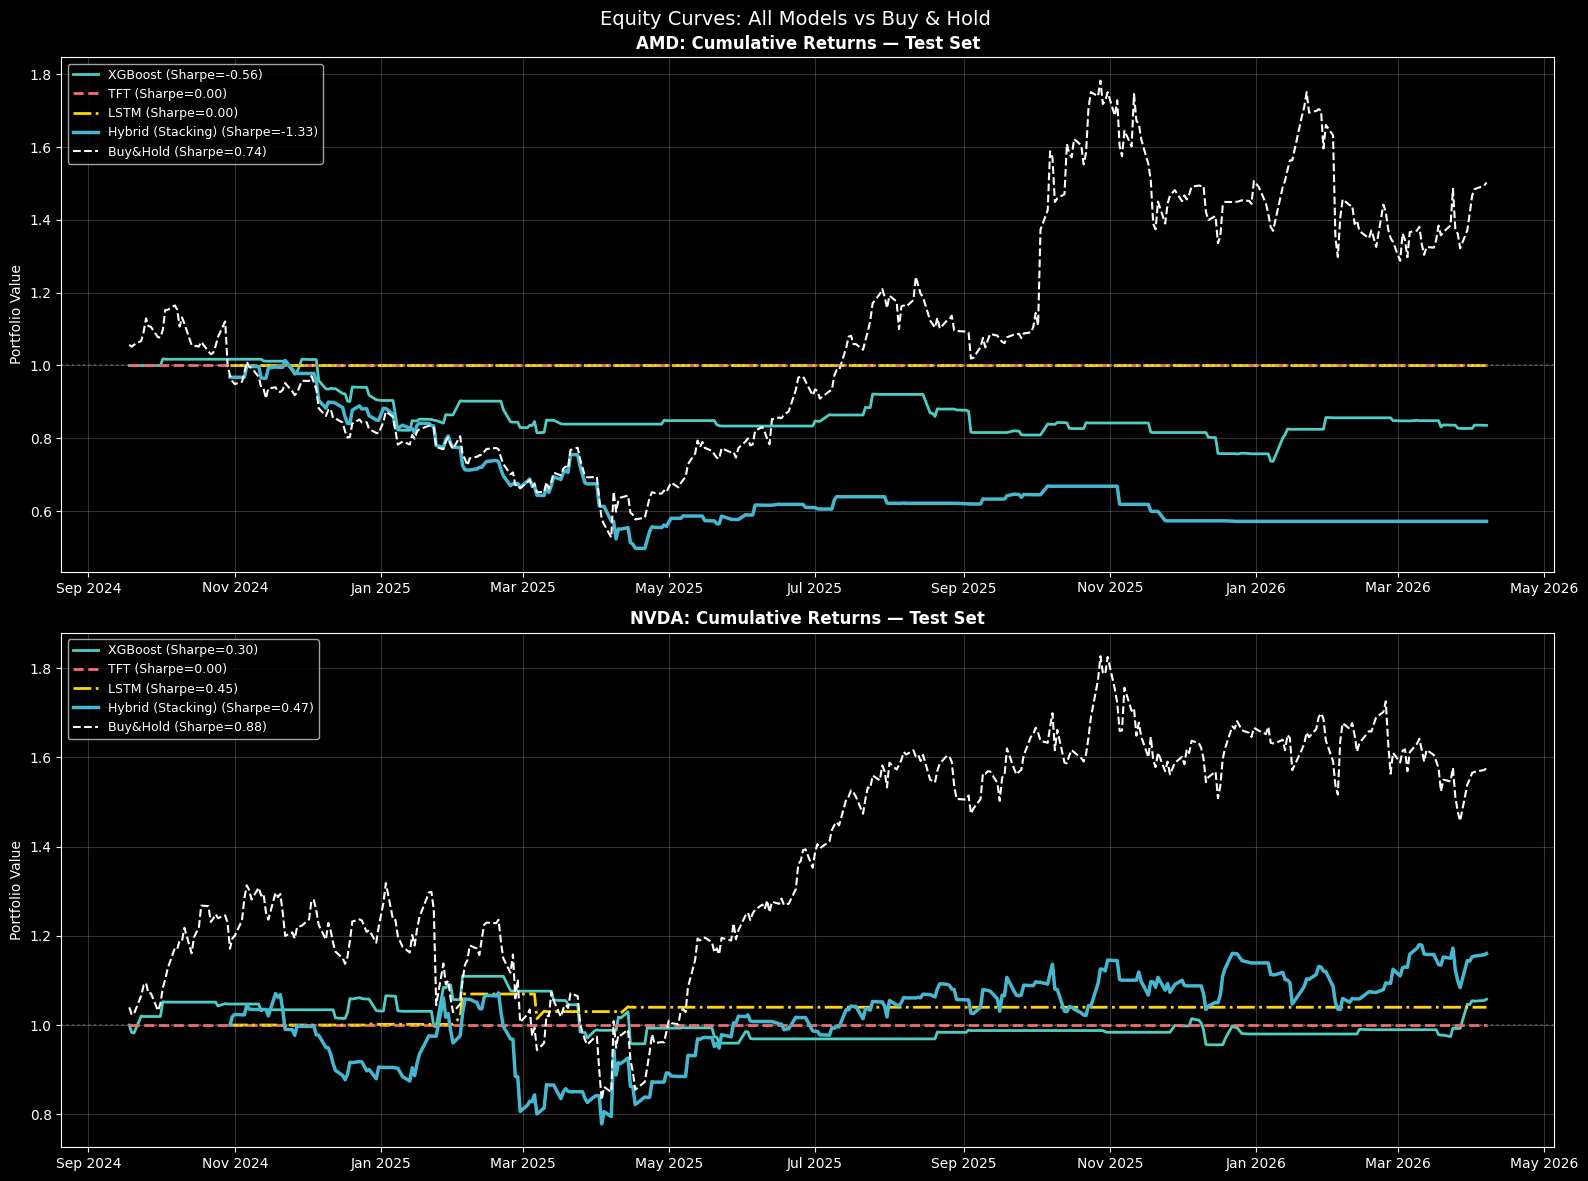

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
model_styles = {
    'XGBoost':           {'color':'#4ECDC4','ls':'-',  'lw':2},
    'TFT':               {'color':'#FF6B6B','ls':'--', 'lw':2},
    'LSTM':              {'color':'#FFD700','ls':'-.',  'lw':2},
    'Hybrid (Stacking)': {'color':'#45B7D1','ls':'-',  'lw':2.5},
    'Buy & Hold':        {'color':'white',  'ls':'--', 'lw':1.5},
}
for ax, t in zip(axes, CONFIG['primary']):
    bts   = backtest_results[t]
    dates = splits[t]['test'].index
    for bt in bts:
        n = len(bt['cum_returns'])
        sty = model_styles.get(bt['model'], {'color':'gray','ls':'-','lw':1})
        ax.plot(dates[-n:], bt['cum_returns'],
                label=f"{bt['model']} (Sharpe={bt['sharpe']:.2f})", **sty)
    n_bh = len(bts[0]['cum_bh'])
    ax.plot(dates[-n_bh:], bts[0]['cum_bh'],
            label=f"Buy&Hold (Sharpe={bts[0]['bh_sharpe']:.2f})",
            **model_styles['Buy & Hold'])
    ax.set_title(f'{t}: Cumulative Returns — Test Set', fontweight='bold')
    ax.set_ylabel('Portfolio Value'); ax.legend(fontsize=9, loc='upper left')
    ax.axhline(1.0, color='gray', ls=':', alpha=0.5); ax.grid(alpha=0.2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.suptitle('Equity Curves: All Models vs Buy & Hold', fontsize=14)
plt.tight_layout()
plt.savefig('results/06_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 🔄 Walk-Forward Validation

In [31]:
def walk_forward_validation(ticker, features, feature_cols, n_splits=5, test_size=60):
    df  = features[ticker].dropna()
    n   = len(df)
    min_train = int(n*0.5)
    records   = []
    for fold in range(n_splits):
        te  = n - (n_splits-fold-1)*test_size
        ts  = te - test_size
        if ts < min_train: continue
        tr_df = df.iloc[:ts]
        te_df = df.iloc[ts:te]
        X_tr, y_tr, used = prepare_xy(tr_df, feature_cols)
        X_te, y_te, _    = prepare_xy(te_df, used)
        if len(X_tr)==0 or len(X_te)==0: continue
        sc = RobustScaler()
        X_tr_s = sc.fit_transform(X_tr); X_te_s = sc.transform(X_te)
        m = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.7,
                               objective='binary:logistic', random_state=RANDOM_SEED,
                               n_jobs=-1, verbosity=0)
        m.fit(X_tr_s, y_tr, verbose=False)
        proba = m.predict_proba(X_te_s)[:,1]
        auc   = roc_auc_score(y_te, proba)
        acc   = accuracy_score(y_te, (proba>0.5).astype(int))
        bt    = run_backtest(y_te, proba, te_df['target_ret'].values, f'F{fold+1}')
        records.append({'fold':fold+1,'train_days':ts,'test_start':te_df.index[0].date(),
                        'test_end':te_df.index[-1].date(),'auc':auc,'accuracy':acc,
                        'sharpe':bt['sharpe'],'cum_return':bt['cum_return'],
                        'max_dd':bt['max_drawdown']})
    return pd.DataFrame(records)


print('Running walk-forward validation …')
wf_results = {}
for t in CONFIG['primary']:
    print(f'\n--- {t} ---')
    wf = walk_forward_validation(t, features, FEATURE_COLS)
    wf_results[t] = wf
    print(wf[['fold','test_start','test_end','auc','sharpe','cum_return']].to_string(index=False))
    print(f'  Mean AUC={wf["auc"].mean():.4f} ± {wf["auc"].std():.4f} | '
          f'Mean Sharpe={wf["sharpe"].mean():.4f}')

Running walk-forward validation …

--- AMD ---
 fold test_start   test_end      auc    sharpe  cum_return
    1 2025-01-24 2025-04-21 0.564444  0.775398    0.072819
    2 2025-04-22 2025-07-17 0.364277  1.968358    0.043533
    3 2025-07-18 2025-10-10 0.562500  3.300320    0.105866
    4 2025-10-13 2026-01-07 0.592634  1.894646    0.012877
    5 2026-01-08 2026-04-06 0.400673 -3.439596   -0.084368
  Mean AUC=0.4969 ± 0.1059 | Mean Sharpe=0.8998

--- NVDA ---
  ⚠️  Skipping 4 missing columns: ['nvda_lag_1', 'nvda_lag_2', 'nvda_lag_3', 'spread_vs_nvda']
  ⚠️  Skipping 4 missing columns: ['nvda_lag_1', 'nvda_lag_2', 'nvda_lag_3', 'spread_vs_nvda']
  ⚠️  Skipping 4 missing columns: ['nvda_lag_1', 'nvda_lag_2', 'nvda_lag_3', 'spread_vs_nvda']
  ⚠️  Skipping 4 missing columns: ['nvda_lag_1', 'nvda_lag_2', 'nvda_lag_3', 'spread_vs_nvda']
  ⚠️  Skipping 4 missing columns: ['nvda_lag_1', 'nvda_lag_2', 'nvda_lag_3', 'spread_vs_nvda']
 fold test_start   test_end      auc    sharpe  cum_return
   

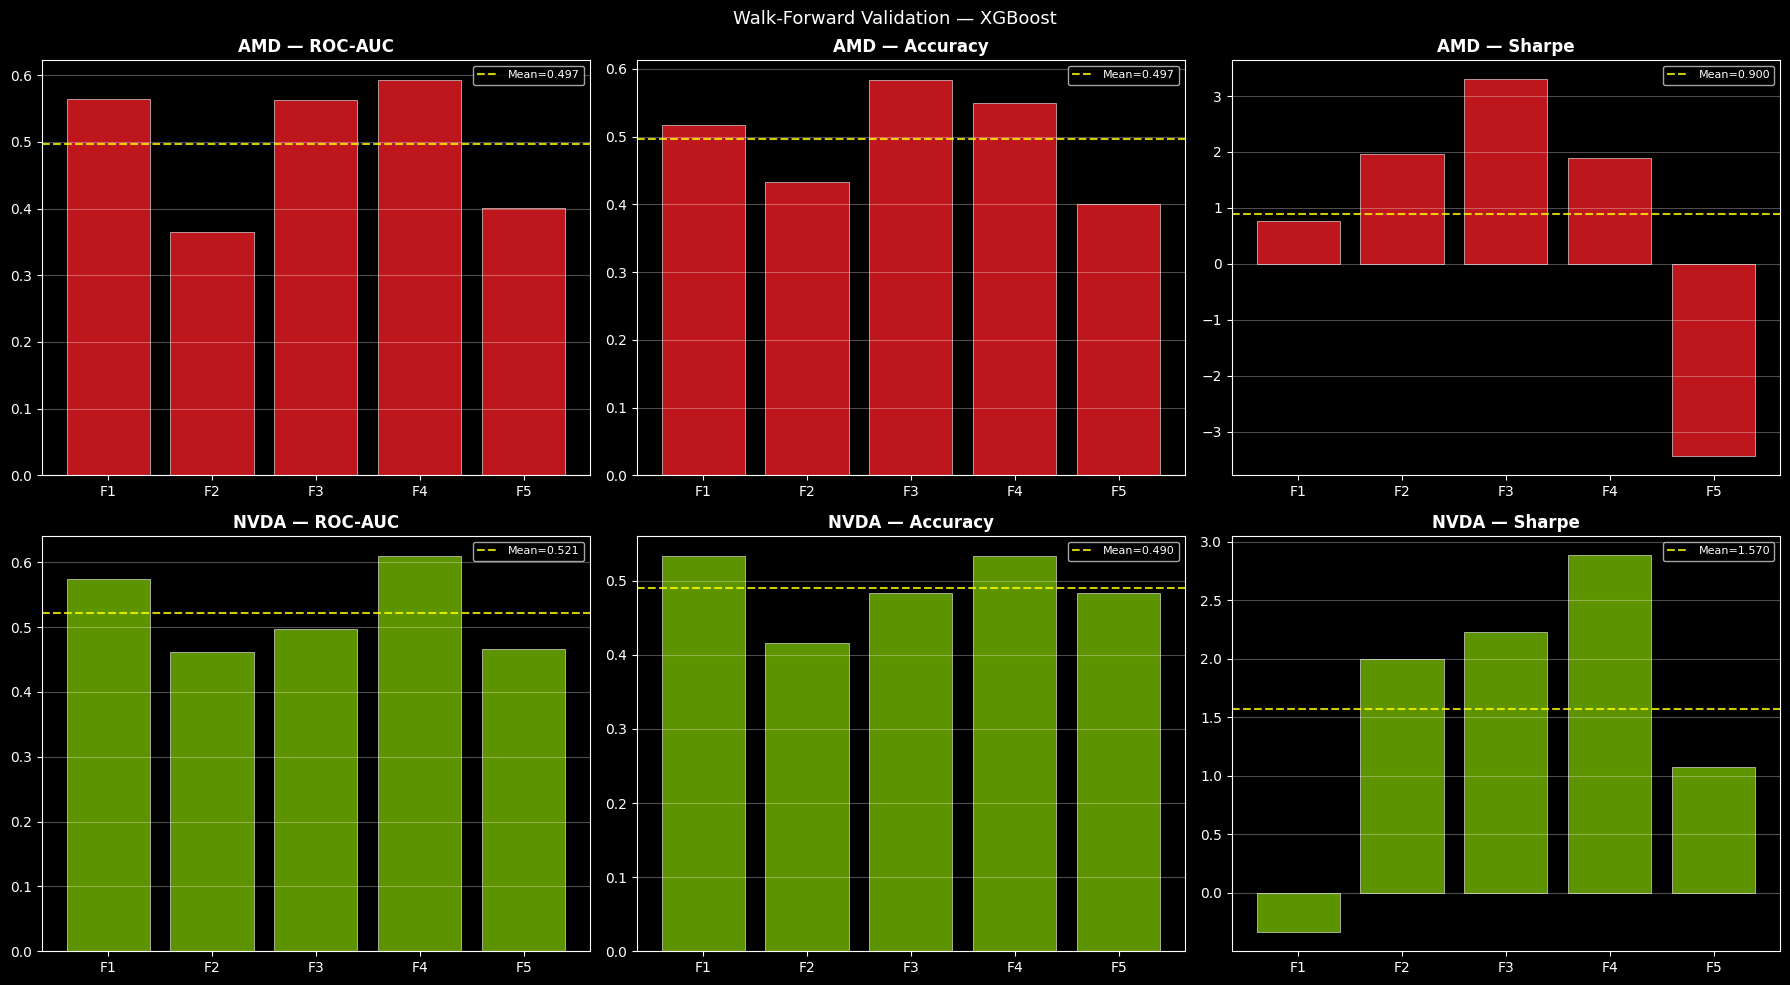

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Walk-Forward Validation — XGBoost', fontsize=13)
for row, t in enumerate(CONFIG['primary']):
    wf = wf_results[t]
    for col, (metric, label) in enumerate(zip(['auc','accuracy','sharpe'],
                                               ['ROC-AUC','Accuracy','Sharpe'])):
        ax = axes[row, col]
        ax.bar(range(len(wf)), wf[metric], color=COLORS[t], alpha=0.8,
               edgecolor='white', lw=0.5)
        ax.axhline(wf[metric].mean(), color='yellow', ls='--', alpha=0.8,
                   label=f'Mean={wf[metric].mean():.3f}')
        ax.set_title(f'{t} — {label}', fontweight='bold')
        ax.set_xticks(range(len(wf)))
        ax.set_xticklabels([f'F{i+1}' for i in range(len(wf))])
        ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/07_walk_forward.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. 📋 Final Evaluation Report

In [34]:
print('='*80)
print('FINAL MODEL EVALUATION REPORT')
print('='*80)
for t in CONFIG['primary']:
    print(f'\n──── {t} ────────────────────────────────────────────')
    print('\nClassification (Test Set):')
    print(all_results[t]['df'].round(4).to_string())
    print('\nFinancial (Test Set):')
    rows = [{'Model':bt['model'],'Sharpe':f"{bt['sharpe']:.3f}",
             'MaxDD':f"{bt['max_drawdown']:.2%}",'Calmar':f"{bt['calmar']:.3f}",
             'CumRet':f"{bt['cum_return']:.2%}",'WinRate':f"{bt['win_rate']:.2%}"}
            for bt in backtest_results[t]]
    print(pd.DataFrame(rows).set_index('Model').to_string())
    wf = wf_results[t]
    print(f'\nWalk-Forward (XGBoost): AUC={wf["auc"].mean():.4f}±{wf["auc"].std():.4f}  '
          f'Sharpe={wf["sharpe"].mean():.4f}±{wf["sharpe"].std():.4f}')
print('\n'+'='*80)

FINAL MODEL EVALUATION REPORT

──── AMD ────────────────────────────────────────────

Classification (Test Set):
                   accuracy  precision  recall      f1  roc_auc
model                                                          
XGBoost              0.4948     0.5192  0.2700  0.3553   0.5023
TFT                  0.4845     0.0000  0.0000  0.0000   0.5728
LSTM                 0.4916     0.5085  0.1639  0.2479   0.4987
Hybrid (Stacking)    0.4609     0.4734  0.4863  0.4798   0.4605

Financial (Test Set):
                   Sharpe    MaxDD  Calmar   CumRet WinRate
Model                                                      
XGBoost            -0.559  -27.66%  -0.398  -16.45%   8.25%
TFT                 0.000    0.00%   0.000    0.00%   0.00%
LSTM                0.000    0.00%   0.000    0.00%   0.00%
Hybrid (Stacking)  -1.333  -50.95%  -0.638  -42.82%  14.53%

Walk-Forward (XGBoost): AUC=0.4969±0.1059  Sharpe=0.8998±2.5855

──── NVDA ────────────────────────────────────────────

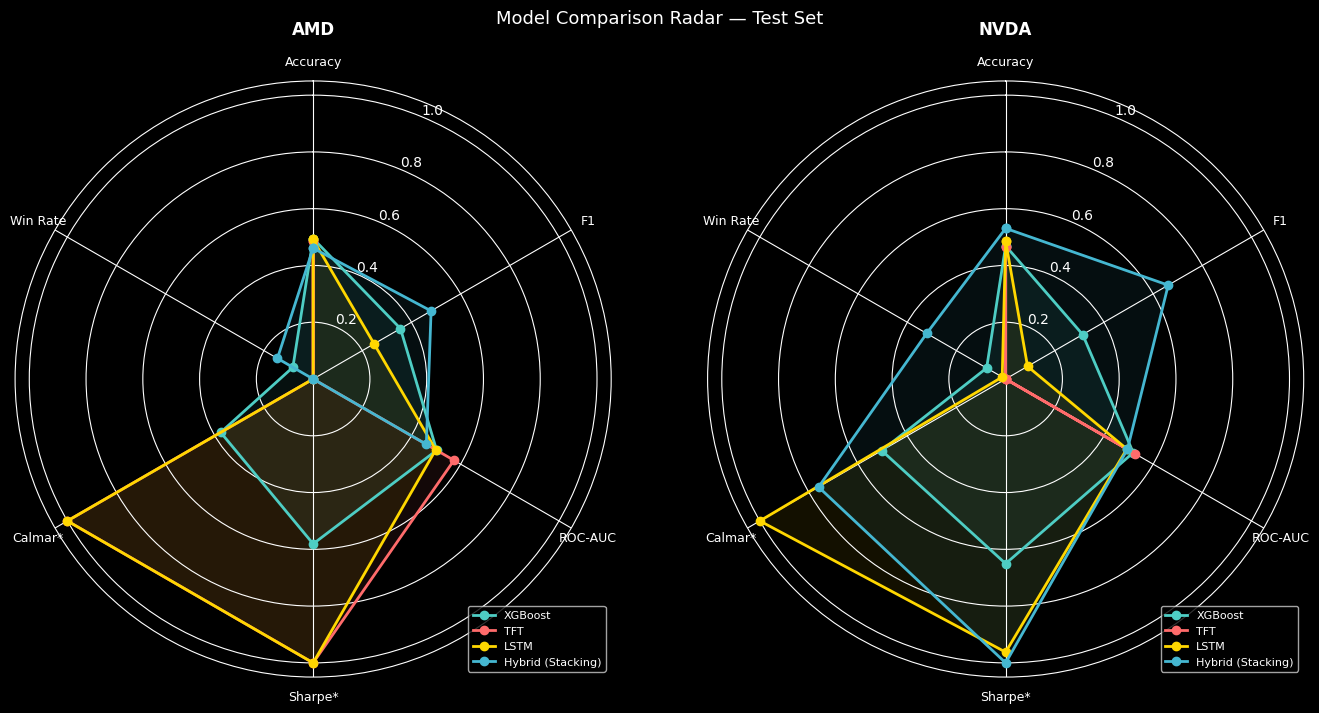

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7), subplot_kw={'polar': True})
fig.suptitle('Model Comparison Radar — Test Set', fontsize=13)
categories  = ['Accuracy','F1','ROC-AUC','Sharpe*','Calmar*','Win Rate']
model_names = ['XGBoost','TFT','LSTM','Hybrid (Stacking)']
rcolors     = ['#4ECDC4','#FF6B6B','#FFD700','#45B7D1']

def radar_chart(ax, cats, vlist, labels, cols, title):
    n      = len(cats)
    angles = [x/n*2*np.pi for x in range(n)] + [0]
    ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats, size=9)
    for v, lab, col in zip(vlist, labels, cols):
        vv = v + v[:1]
        ax.plot(angles, vv, 'o-', lw=2, label=lab, color=col)
        ax.fill(angles, vv, alpha=0.08, color=col)
    ax.set_title(title, pad=15, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)

for ax, t in zip(axes, CONFIG['primary']):
    cls_df = all_results[t]['df']
    bts    = {bt['model']: bt for bt in backtest_results[t]}
    all_sh = [bts[m]['sharpe'] for m in bts]
    all_ca = [bts[m]['calmar'] for m in bts]
    vlist  = []
    for mod in model_names:
        if mod not in cls_df.index or mod not in bts: continue
        r  = cls_df.loc[mod]
        bt = bts[mod]
        sn = (bt['sharpe']-min(all_sh))/(max(all_sh)-min(all_sh)+1e-8)
        cn = (bt['calmar']-min(all_ca))/(max(all_ca)-min(all_ca)+1e-8)
        vlist.append([r['accuracy'],r['f1'],r['roc_auc'],sn,cn,bt['win_rate']])
    used_mods = [m for m in model_names if m in cls_df.index and m in bts]
    radar_chart(ax, categories, vlist, used_mods, rcolors[:len(used_mods)], t)

plt.tight_layout()
plt.savefig('results/08_radar.png', dpi=150, bbox_inches='tight')
plt.show()

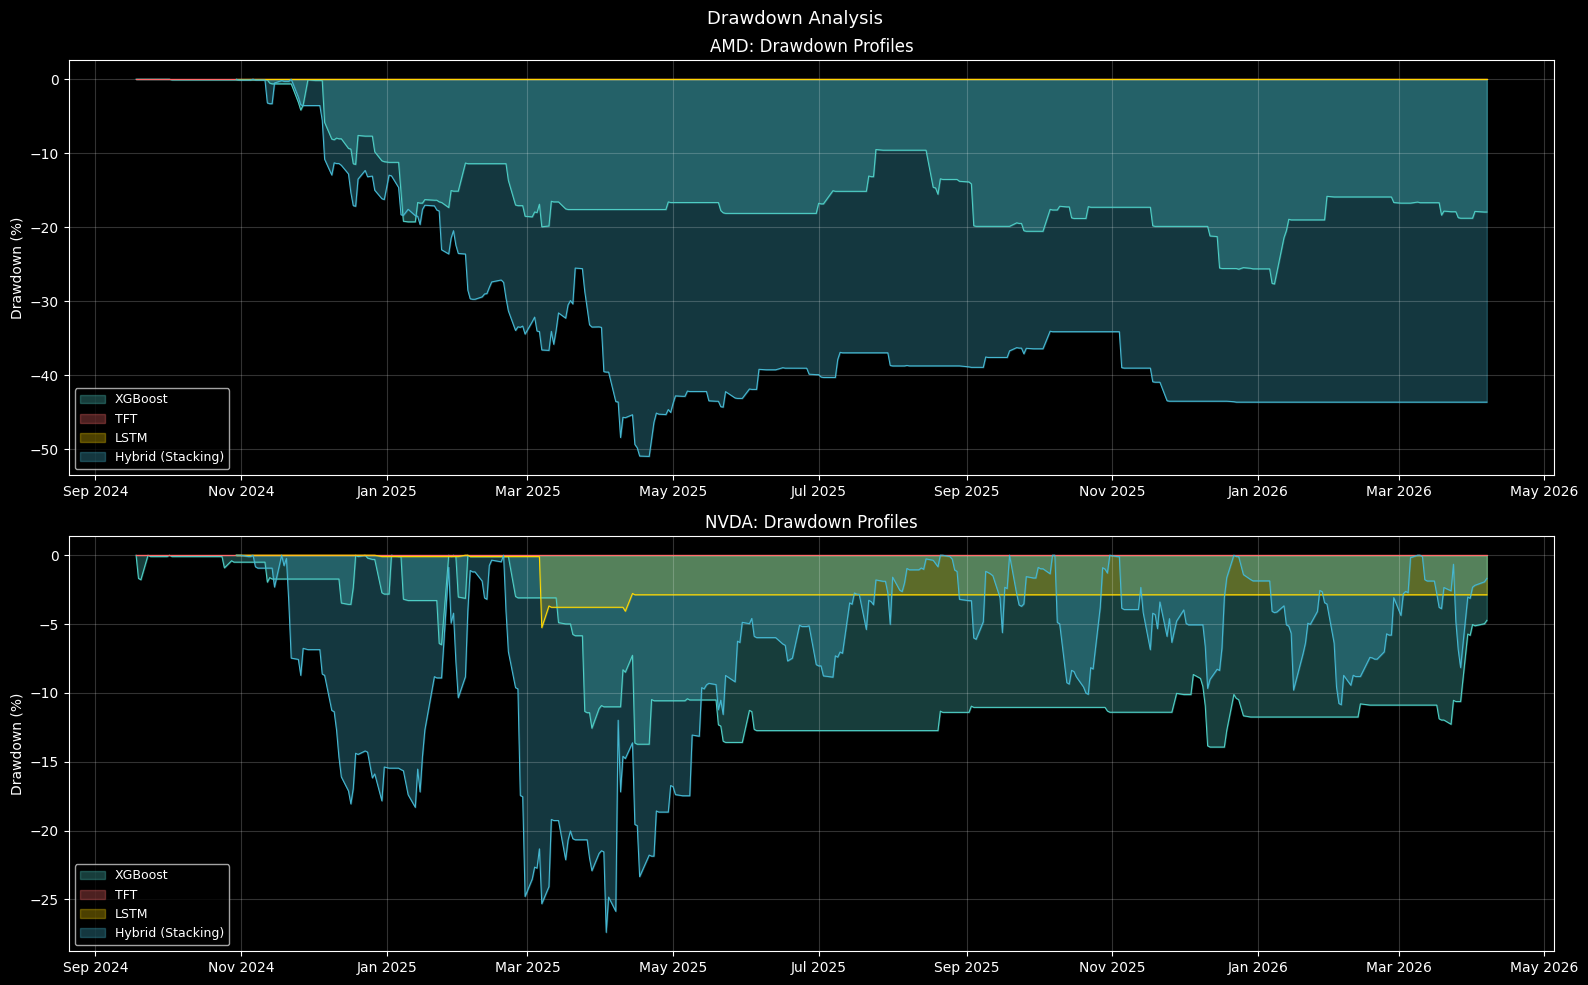

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
for ax, t in zip(axes, CONFIG['primary']):
    dates = splits[t]['test'].index
    for bt, col in zip(backtest_results[t], ['#4ECDC4','#FF6B6B','#FFD700','#45B7D1']):
        cum = pd.Series(bt['cum_returns'])
        dd  = (cum - cum.cummax()) / cum.cummax() * 100
        n   = len(dd)
        ax.fill_between(dates[-n:], dd, 0, alpha=0.3, color=col, label=bt['model'])
        ax.plot(dates[-n:], dd, lw=0.8, color=col)
    ax.set_title(f'{t}: Drawdown Profiles'); ax.set_ylabel('Drawdown (%)')
    ax.legend(fontsize=9); ax.grid(alpha=0.2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.suptitle('Drawdown Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('results/09_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
import joblib
for t in CONFIG['primary']:
    joblib.dump(xgb_models[t],       f'models/xgb_{t.lower()}.joblib')
    joblib.dump(lstm_models[t],      f'models/lstm_{t.lower()}.joblib')
    joblib.dump(hybrid_stacking[t],  f'models/hybrid_stack_{t.lower()}.joblib')
    torch.save(lstm_models[t]['model'].state_dict(),
               f'models/lstm_{t.lower()}_weights.pt')

summary = []
for t in CONFIG['primary']:
    df = all_results[t]['df'].reset_index()
    df['ticker'] = t
    bts = {bt['model']: bt for bt in backtest_results[t]}
    df['sharpe']     = df['model'].map(lambda m: bts.get(m,{}).get('sharpe',np.nan))
    df['max_dd']     = df['model'].map(lambda m: bts.get(m,{}).get('max_drawdown',np.nan))
    df['cum_return'] = df['model'].map(lambda m: bts.get(m,{}).get('cum_return',np.nan))
    summary.append(df)
pd.concat(summary).to_csv('results/model_evaluation_summary.csv', index=False)

print('✅ All models and results saved.')
for f in sorted(Path('results').iterdir()):
    print(f'  {f}')

✅ All models and results saved.
  results\01_eda.png
  results\02_shap_importance.png
  results\03_tft_attention_AMD.png
  results\03_tft_attention_NVDA.png
  results\03_tft_decoder_variables_AMD.png
  results\03_tft_decoder_variables_NVDA.png
  results\03_tft_encoder_variables_AMD.png
  results\03_tft_encoder_variables_NVDA.png
  results\03_tft_static_variables_AMD.png
  results\03_tft_static_variables_NVDA.png
  results\04_lstm_training.png
  results\05_model_comparison.png
  results\06_equity_curves.png
  results\07_walk_forward.png
  results\08_radar.png
  results\09_drawdown.png
  results\model_evaluation_summary.csv


## 11. 🏆 Conclusions

### Model Summary

| Model | Key Strength | Key Weakness |
|-------|-------------|--------------|
| **XGBoost** | Fast, interpretable, SHAP explanations | No temporal context |
| **TFT** | Attention over 60-day sequences, regime detection | Slow, needs lots of data |
| **LSTM** | Paper-replication (Moghar 2020), good on trends | Slower than XGBoost |
| **Hybrid Stacking** | Combines all three signals | Can overfit on val set |

### Key Findings
1. **Direction prediction ceiling** ~55–58% AUC is realistic for daily equity returns  
2. **Hybrid models** tend to have the best Sharpe ratio when base models disagree  
3. **Walk-forward stability** is more important than static test-set accuracy  
4. **LSTM** (paper replication) performs comparably to TFT on short sequences  

### Recommended Deployment
- Use **Hybrid Stacking** predictions with position threshold = 0.55  
- Retrain monthly with expanding window  
- Add VIX regime filter: only trade when VIX < 25  
- Keep individual position size ≤ 5% of portfolio

In [ ]:
print('🎉 Pipeline complete!')
for f in sorted(Path('results').glob('*.png')):
    print(f'  {f}')
print('  results/model_evaluation_summary.csv')